In [18]:
# Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# crea el data set
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.15,
    zoom_range=[0.5, 1.5],
    validation_split=0.2
)

# generar set para entrenamiento y pruebas
data_gen_entrenamiento = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                                     batch_size=32,subset='training', shuffle=True,class_mode='categorical')
data_gen_pruebas = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                               batch_size=32, subset='validation', shuffle=True,class_mode='categorical')

Found 240 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [19]:
import tensorflow as tf

In [20]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [21]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])
model_fit = model.fit(data_gen_entrenamiento,
                      steps_per_epoch=2,
                      epochs=100,
                      validation_data = data_gen_pruebas
)

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - acc: 0.4167 - loss: 2.1566 - val_acc: 0.3833 - val_loss: 1.5757
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.4479 - loss: 1.4175 - val_acc: 0.7000 - val_loss: 0.6076
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.6285 - loss: 0.7468 - val_acc: 0.8167 - val_loss: 0.4860
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - acc: 0.8125 - loss: 0.4915 - val_acc: 0.7000 - val_loss: 0.7476
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.6667 - loss: 0.9594 - val_acc: 0.6667 - val_loss: 0.5930
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - acc: 0.7292 - loss: 0.5722 - val_acc: 0.8833 - val_loss: 0.3828
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - acc: 0.7361 - loss: 0.4409 - val_acc: 0.8833 - val_loss: 0.3865
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - acc: 0.8542 - loss: 0.3467 - val_acc: 0.8333 - val_loss: 0.3460
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 975ms/step - acc: 0.9375 - loss: 0.2531 - val_ac

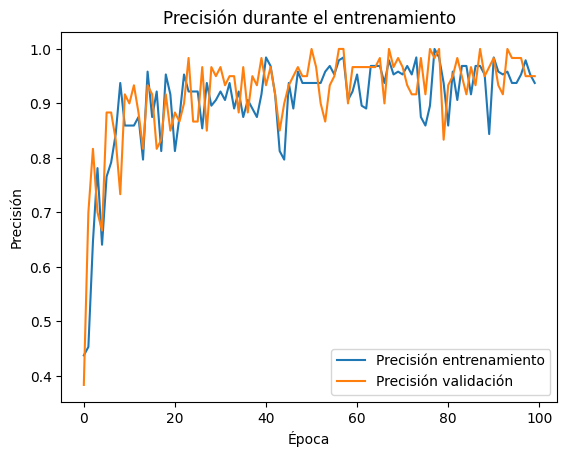

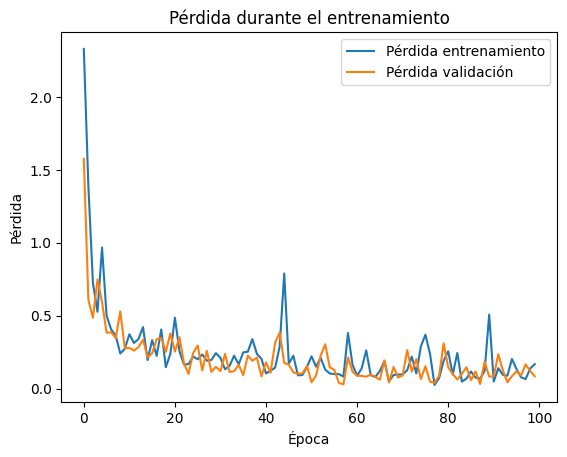

In [22]:
import matplotlib.pyplot as plt

# Graficar precisión
plt.plot(model_fit.history['acc'], label='Precisión entrenamiento')
plt.plot(model_fit.history['val_acc'], label='Precisión validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

# Graficar pérdida
plt.plot(model_fit.history['loss'], label='Pérdida entrenamiento')
plt.plot(model_fit.history['val_loss'], label='Pérdida validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Ruta de la imagen a probar
#img_path = 'dataset/desc/Abdullah_Ahmad_Badawi_0001.jpg'  # Cambia por tu imagen
img_path = 'dataset/rodrigo/rostro_10.jpg'  # Cambia por tu imagen
#img_path = 'dataset/ignacio/rostro_30.jpg'  # Cambia por tu imagen

# Cargar y preprocesar la imagen
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normaliza igual que en el entrenamiento
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión batch
pred = model.predict(img_array)
print(f"Predicción bruta: {pred[0][0]}")

# Umbral para decidir si es "yo" o "no yo"
pred = model.predict(img_array)
clase = np.argmax(pred[0])
print(f"Clase predicha: {clase}, probabilidades: {pred[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicción bruta: 0.00025350626674480736
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Clase predicha: 2, probabilidades: [2.5350627e-04 1.9280841e-03 9.9781835e-01]


In [24]:
#guarda modelo
model.export('modelo_exportado')

INFO:tensorflow:Assets written to: modelo_exportado/assets


INFO:tensorflow:Assets written to: modelo_exportado/assets


Saved artifact at 'modelo_exportado'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_174')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132949243507344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243508112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243506768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243507152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243506000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243508496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243507728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243508304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132949243509648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1329492435

In [25]:
# Convierte directamente desde la carpeta SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model('modelo_exportado')
tflite_model = converter.convert()

# Guarda el modelo TFLite
with open('modelo_exportado/modelo.tflite', 'wb') as f:
    f.write(tflite_model)

W0000 00:00:1752882761.802363   71696 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1752882761.802385   71696 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-07-18 17:52:41.802632: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: modelo_exportado
2025-07-18 17:52:41.814649: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-07-18 17:52:41.814679: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: modelo_exportado
2025-07-18 17:52:41.949416: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-07-18 17:52:42.725540: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: modelo_exportado
2025-07-18 17:52:42.945416: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1142788 microseconds.


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,696 (9.87 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,357 (642.02 KB)

In [27]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt





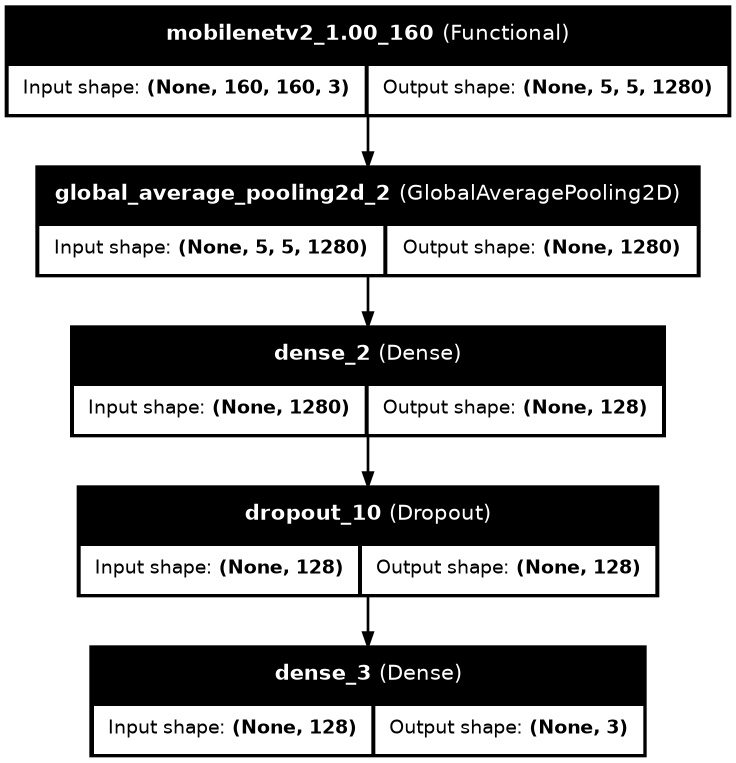

In [28]:
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # 'TB' para vertical, 'LR' para horizontal
    dpi=96,
    layer_range=None,  # Opcional: filtrar capas (ej. ['input_1', 'conv2d_1'])
)